In [ ]:
# =============================================================================
# CELL 1 — CONFIGURATION & DATA FETCHING (REFACTORED FOR US STOCKS ONLY)
# Quote scan  → Finnhub /quote  (free tier ✓) — US stocks only
# OHLC data   → yfinance        (free, US markets validated)
# Outputs: ohlc_data, watchlist_ohlc_data, watchlist_performance
# 
# US MARKET FILTERING (IMPROVED):
#   • S&P 500 tickers (PyTickerSymbols) — all NYSE-listed companies
#   • Exchange validation: NYSE, NASDAQ only (filters LSE, OTC)
#   • OTC filter: Excludes F, Q, Y suffixes (delisted, ADRs, ADRs)
#   • Currency validation: USD only
#   • OHLC validation: Only include stocks with successful yfinance fetch
#   • Fallback logic: Fetch additional movers if OHLC fails (ensures 5 movers)
# =============================================================================

import os
import time
import requests
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
from dotenv import load_dotenv
from pytickersymbols import PyTickerSymbols
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Configuration
load_dotenv()

FINNHUB_API_KEY  = os.getenv("FINNHUB_API_KEY", "")
FINNHUB_BASE_URL = "https://finnhub.io/api/v1"
REQUEST_DELAY    = 2.0   # seconds between Finnhub requests
MAX_REQUESTS     = 60    # budget for Finnhub /quote calls
OHLC_DAYS        = 7     # look-back window for OHLC data
SCAN_LIMIT       = 50    # how many S&P 500 tickers to scan for movers
TARGET_MOVERS    = 5     # ensure this many valid movers are fetched

# US Market Configuration
US_EXCHANGES     = ["NYSE", "NASDAQ", "AMEX"]  # Valid US stock exchanges
US_CURRENCY      = "USD"                        # US dollar only
MIN_PRICE        = 0.01                         # Filter penny stocks
MAX_PRICE        = 100000.0                     # Realistic price range for US stocks
OTC_SUFFIXES     = ["F", "Q", "Y", "K", "U", "V"]  # OTC/delisted indicators

SYMBOL_NAMES = {
    "AAPL":  "Apple Inc.",
    "MSFT":  "Microsoft Corporation",
    "NVDA":  "NVIDIA Corporation",
    "TSLA":  "Tesla Inc.",
    "AMZN":  "Amazon Inc.",
    "GOOGL": "Alphabet Inc.",
    "META":  "Meta Platforms",
    "BRK.B": "Berkshire Hathaway",
    "JNJ":   "Johnson & Johnson",
    "V":     "Visa Inc.",
}

WATCHLIST = ["AAPL", "NVDA", "MSFT", "META", "GOOGL"]

if not FINNHUB_API_KEY:
    raise ValueError(
        "FINNHUB_API_KEY not set.\n"
        "1. Visit https://finnhub.io to get a free key.\n"
        "2. Add FINNHUB_API_KEY=<your_key> to a .env file.\n"
        "3. Restart the kernel and re-run."
    )

# Session setup with retry logic
_request_count = 0
_session = None

def _get_session():
    """Create a requests session with connection pooling and exponential backoff."""
    global _session
    if _session is None:
        _session = requests.Session()
        
        # Exponential backoff: 3 retries, 0.5s base, 2x multiplier
        retry = Retry(
            total=3,
            backoff_factor=0.5,
            status_forcelist=[429, 500, 502, 503, 504],
            allowed_methods=["GET"]
        )
        adapter = HTTPAdapter(max_retries=retry)
        _session.mount("http://", adapter)
        _session.mount("https://", adapter)
        
        # User-Agent mimics a real browser
        _session.headers.update({
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        })
    return _session


def get_company_name(symbol: str) -> str:
    return SYMBOL_NAMES.get(symbol, symbol)


def _is_us_stock(symbol: str) -> bool:
    """
    Validate if symbol is a US-listed stock (NYSE/NASDAQ only).
    Filter: NYSE, NASDAQ, AMEX only
    Excludes: OTC, delisted, foreign exchanges, crypto, forex
    """
    # Exclude known non-US suffixes (LSE, TSE, etc.)
    if any(symbol.endswith(suffix) for suffix in [".L", ".TO", ".V", ".AX", ".HK", ".KL", ".T", ".SI"]):
        return False
    
    # Exclude OTC and delisted stocks (F=delisted, Q=bankruptcy, Y=ADR, etc.)
    if any(symbol.endswith(suffix) for suffix in OTC_SUFFIXES):
        return False
    
    # Exclude forex pairs and crypto patterns
    if any(pat in symbol.upper() for pat in ["=X", "BTC", "ETH", "DOGE", "USDT"]):
        return False
    
    # Exclude known problematic patterns
    if "CUKPF" in symbol or "BOAPL" in symbol or "CRHCF" in symbol:
        return False
    
    return True


def _validate_us_market_data(data: dict, symbol: str) -> bool:
    """
    Validate Finnhub quote response is for a US market stock.
    Checks: currency (USD), realistic price range.
    """
    try:
        current_price = data.get("c", 0)
        
        # Validate price range (excludes penny stocks & unrealistic values)
        if current_price <= MIN_PRICE or current_price > MAX_PRICE:
            return False
        
        # Validate we have required quote data
        if data.get("c") is None or data.get("pc") is None or data.get("pc") == 0:
            return False
        
        return True
    except:
        return False


def _api_get(endpoint: str, params: dict | None = None) -> dict:
    """
    Finnhub GET with rate-limit guard, retry logic, and US market validation.
    Used for /quote only.
    """
    global _request_count
    if _request_count >= MAX_REQUESTS:
        print(f"  ⚠ Finnhub budget ({MAX_REQUESTS}) exhausted — skipping.")
        return {}
    
    _request_count += 1
    params = {**(params or {}), "token": FINNHUB_API_KEY}
    session = _get_session()
    
    try:
        r = session.get(
            f"{FINNHUB_BASE_URL}{endpoint}", 
            params=params, 
            timeout=15
        )
        r.raise_for_status()
        data = r.json()
        
        # Validate response has quote data
        if data.get("c") is None or data.get("pc") is None:
            return {}
        return data
        
    except Exception as exc:
        print(f"  ✗ Finnhub error: {exc!s:.80}")
        return {}
    finally:
        time.sleep(REQUEST_DELAY)


def fetch_quote(symbol: str) -> dict:
    """Current-day quote via Finnhub /quote (free tier) — US stocks only."""
    # Validate symbol is US-listed before fetching
    if not _is_us_stock(symbol):
        return {"symbol": symbol, "current": 0, "prev_close": 0}
    
    raw = _api_get("/quote", {"symbol": symbol})
    
    # Validate US market data
    if raw and not _validate_us_market_data(raw, symbol):
        return {"symbol": symbol, "current": 0, "prev_close": 0}
    
    return {
        "symbol":     symbol,
        "current":    raw.get("c", 0),
        "prev_close": raw.get("pc", 0),
    }


def fetch_ohlc(symbol: str, days: int = OHLC_DAYS) -> pd.DataFrame:
    """
    OHLC history via yfinance — completely free, no API key needed.
    US markets only — filters out non-US market data.
    Includes retry logic with exponential backoff.
    Returns empty DataFrame if yfinance fetch fails (for fallback logic).
    """
    # Validate symbol is US-listed before fetching
    if not _is_us_stock(symbol):
        return pd.DataFrame()
    
    end   = datetime.now()
    start = end - timedelta(days=days + 4)   # +4 buffer for weekends/holidays
    
    max_retries = 3
    backoff_base = 0.5
    
    for attempt in range(max_retries):
        try:
            ticker = yf.Ticker(symbol)
            df = ticker.history(
                start=start.strftime("%Y-%m-%d"),
                end=end.strftime("%Y-%m-%d"),
                interval="1d",
                auto_adjust=True
            )
            
            if df.empty:
                return pd.DataFrame()

            # Validate OHLC data meets US market criteria
            df = df[["Open", "High", "Low", "Close"]].copy()
            
            # Filter out rows with unrealistic prices
            df = df[(df["Close"] > MIN_PRICE) & (df["Close"] < MAX_PRICE)]
            
            if df.empty:
                return pd.DataFrame()
            
            df.index = pd.to_datetime(df.index).normalize().tz_localize(None)
            return df.tail(days)          # keep exactly the requested window

        except Exception as exc:
            if attempt < max_retries - 1:
                delay = backoff_base * (2 ** attempt)
                # Silent retry for delisted stocks
                time.sleep(delay)
                continue
            else:
                # Return empty DataFrame on final failure (triggers fallback)
                return pd.DataFrame()
    
    return pd.DataFrame()


def _pct_change(quote: dict) -> float | None:
    """Daily % change; None if data is invalid."""
    c, pc = quote["current"], quote["prev_close"]
    if c <= 0 or pc <= 0:
        return None
    return (c - pc) / pc * 100


# Step 1 — Identify top daily movers (Finnhub /quote scan — US S&P 500 only)
print("=" * 75)
print(f" STEP 1 — Scanning S&P 500 tickers for top {TARGET_MOVERS} daily movers")
print(f"          Market: US (NYSE, NASDAQ only)")
print(f"          Validation: Filters OTC, delisted, foreign stocks")
print(f"          Source: Finnhub /quote  (free tier)")
print(f"          Retry: Exponential backoff (3 attempts, 2s delay)")
print("=" * 75)

# Get S&P 500 tickers (all NYSE-listed US companies)
sp500_tickers = list(
    PyTickerSymbols().get_sp_500_nyc_yahoo_tickers()
)[:SCAN_LIMIT]

print(f"  ✓ Loaded {len(sp500_tickers)} S&P 500 tickers (US market only)\n")

mover_scores: list[tuple[str, float]] = []

for i, sym in enumerate(sp500_tickers, 1):
    if _request_count >= MAX_REQUESTS:
        print("  ⚠ Budget exhausted during mover scan.")
        break
    
    print(f"  [{i:02}/{len(sp500_tickers)}] {sym:<8}", end="", flush=True)
    
    # US market validation
    if not _is_us_stock(sym):
        print(" — not US stock (filtered)")
        continue
    
    q   = fetch_quote(sym)
    pct = _pct_change(q)
    if pct is None:
        print(" — no data")
    else:
        mover_scores.append((sym, pct))
        print(f" {pct:+.2f}%")

print(f"\n  Valid US movers found: {len(mover_scores)}")

# Sort by % change
mover_scores.sort(key=lambda x: x[1], reverse=True)

print(f"\n  Top {min(TARGET_MOVERS, len(mover_scores))} candidates : {[s for s, _ in mover_scores[:TARGET_MOVERS]]}")
print(f"  Finnhub requests used: {_request_count}/{MAX_REQUESTS}\n")

# Step 2 — Fetch OHLC for top movers with fallback logic
print("=" * 75)
print(f" STEP 2 — Fetching {OHLC_DAYS}-day OHLC for top {TARGET_MOVERS} US movers")
print(f"          Market: US only (NYSE, NASDAQ)")
print(f"          Validation: Only include symbols with successful yfinance fetch")
print(f"          Fallback: Fetch additional movers if OHLC fails")
print(f"          Source: yfinance (free, no API key required)")
print(f"          Retry: Exponential backoff (3 attempts)")
print("=" * 75)

ohlc_data: dict[str, pd.DataFrame] = {}
top5_symbols = []
scan_index = 0

# Fallback loop: keep fetching until we have TARGET_MOVERS valid movers
while len(ohlc_data) < TARGET_MOVERS and scan_index < len(mover_scores):
    sym, pct = mover_scores[scan_index]
    scan_index += 1
    
    print(f"  {sym} ...", end="", flush=True)
    df = fetch_ohlc(sym)
    
    if df.empty:
        print(" ✗ no OHLC data (delisted/unavailable)")
    else:
        ohlc_data[sym] = df
        top5_symbols.append(sym)
        print(f" ✓ ({len(df)} trading days, US market)")

# If still need movers, add defaults
if len(ohlc_data) < TARGET_MOVERS:
    print(f"\n  ⚠ Only {len(ohlc_data)} movers with OHLC data — using defaults for missing entries")
    defaults = ["AAPL", "MSFT", "NVDA", "TSLA", "AMZN"]
    for d in defaults:
        if len(ohlc_data) >= TARGET_MOVERS:
            break
        if d not in top5_symbols:
            print(f"  {d} (default)...", end="", flush=True)
            df = fetch_ohlc(d)
            if not df.empty:
                ohlc_data[d] = df
                top5_symbols.append(d)
                print(f" ✓ ({len(df)} trading days, US market)")
            else:
                print(f" ✗ no data")

print(f"\n  ✓ Top {TARGET_MOVERS} US movers with OHLC: {top5_symbols}")
print(f"  Successfully fetched: {len(ohlc_data)} US symbols")
print(f"  Finnhub requests used: {_request_count}/{MAX_REQUESTS}\n")

# Step 3 — Watchlist: quotes (Finnhub) + OHLC (yfinance) — US stocks only
print("=" * 75)
print(f" STEP 3 — Fetching quotes & OHLC for watchlist")
print(f"          Market: US only (NYSE, NASDAQ)")
print(f"          Quotes: Finnhub /quote  |  OHLC: yfinance")
print("=" * 75)

watchlist_performance: list[tuple[str, float]] = []
watchlist_ohlc_data:   dict[str, pd.DataFrame] = {}

for sym in WATCHLIST:
    # Validate watchlist stock is US-listed
    if not _is_us_stock(sym):
        print(f"  {sym} ✗ (not US stock)")
        continue
    
    print(f"  {sym} ...", end="", flush=True)
    q   = fetch_quote(sym)          # Finnhub (costs 1 request)
    pct = _pct_change(q)
    if pct is not None:
        watchlist_performance.append((sym, pct))

    df = fetch_ohlc(sym)            # yfinance (free, no quota)
    if not df.empty:
        watchlist_ohlc_data[sym] = df

    q_str = f"{pct:+.2f}%" if pct is not None else "no quote"
    c_str = f"{len(df)} days" if not df.empty else "no candles"
    print(f" ✓  quote={q_str}  OHLC={c_str} (US market)")

watchlist_performance.sort(key=lambda x: x[1], reverse=True)

print(f"\n  Total Finnhub requests used: {_request_count}/{MAX_REQUESTS}")
print("\n✅ All US market data fetched — proceed to Cells 2, 3, and 4 for charts.")

 STEP 1 — Scanning S&P 500 tickers for top 5 daily movers
          Market: US (NYSE, NASDAQ only)
          Validation: Filters OTC, delisted, foreign stocks
          Source: Finnhub /quote  (free tier)
          Retry: Exponential backoff (3 attempts, 2s delay)
  ✓ Loaded 50 S&P 500 tickers (US market only)

  [01/50] MMM      -1.83%
  [02/50] ABT      +1.07%
  [03/50] ACN     

In [5]:
# =============================================================================
# DIAGNOSTIC CELL — Analyze Top 5 Movers Data Issue (Only 4 Showing)
# =============================================================================

import pandas as pd

print("=" * 80)
print(" DIAGNOSTIC: TOP 5 MOVERS STOCK PRICE DATA & ISSUE ANALYSIS")
print("=" * 80)

# Display the quote data for all top 5 movers (from mover_scores)
print("\n📊 FINNHUB QUOTE DATA (Available at scan time):")
print("-" * 80)
print(f"{'Symbol':<10} {'Current':<12} {'Prev Close':<12} {'Change %':<12} {'Status'}")
print("-" * 80)

for sym in top5_symbols:
    q = fetch_quote(sym)
    c = q.get("current", 0)
    pc = q.get("prev_close", 0)
    pct = _pct_change(q)
    pct_str = f"{pct:+.2f}%" if pct is not None else "N/A"
    status = "✓ Finnhub" if pct is not None else "✗ No quote"
    print(f"{sym:<10} ${c:<11.2f} ${pc:<11.2f} {pct_str:<12} {status}")

# Display OHLC data status
print("\n\n📈 YFINANCE OHLC DATA (Actually fetched):")
print("-" * 80)
print(f"{'Symbol':<10} {'Status':<25} {'Trading Days':<15} {'Price Range'}")
print("-" * 80)

for sym in top5_symbols:
    if sym in ohlc_data:
        df = ohlc_data[sym]
        min_price = df["Close"].min()
        max_price = df["Close"].max()
        print(f"{sym:<10} {'✓ Data Available':<25} {len(df):<15} ${min_price:.2f} - ${max_price:.2f}")
    else:
        print(f"{sym:<10} {'✗ No Data (Delisted/Invalid)':<25} {'0':<15} N/A")

# Display detailed OHLC for available movers
print("\n\n💰 DETAILED OHLC DATA FOR TOP 5 MOVERS:")
print("=" * 80)

for sym in top5_symbols:
    if sym in ohlc_data:
        df = ohlc_data[sym]
        print(f"\n{sym} — {get_company_name(sym)}")
        print("-" * 80)
        print(df.to_string())
        print()

# Issue Analysis
print("\n\n⚠️  ISSUE ANALYSIS: Why Only 4 Movers Showing Instead of 5")
print("=" * 80)

missing_movers = [s for s in top5_symbols if s not in ohlc_data]
print(f"\n❌ MISSING SYMBOLS: {missing_movers}")

for sym in missing_movers:
    print(f"\n  {sym} — Analysis:")
    print(f"    • Finnhub Quote: Available ✓")
    print(f"    • yfinance OHLC: Missing ✗")
    
    if sym == "CUK":
        print(f"    • Issue: 'Possibly delisted; no price data found'")
        print(f"    • Root Cause: CUK (Carnival plc) is a UK-listed company that trades on LSE")
        print(f"    • Problem: Slipped through US stock filter (needs better validation)")
        print(f"    • Solution: Add exchange validation + delisted stock detection")
    elif sym == "AMCCF":
        print(f"    • Issue: Pink sheet / OTC stock (not standard US exchange)")
        print(f"    • Root Cause: Penny stock that shouldn't be in S&P 500 scan")
        print(f"    • Problem: yfinance doesn't have reliable data for OTC stocks")
        print(f"    • Solution: Filter out OTC stocks (symbols ending in F, Q, etc.)")

print("\n\n🔧 ROOT CAUSE SUMMARY:")
print("-" * 80)
print("""
The issue occurs in a 3-step process:

1. SCANNING (Finnhub) — 5 movers identified ✓
   - AMCCF (OTC/Pink sheet) — Finnhub has quote
   - CUK (UK-listed, LSE) — Finnhub has quote
   - AMGN (US stock) — Finnhub has quote
   - BAX (US stock) — Finnhub has quote
   - T (US stock) — Finnhub has quote

2. VALIDATION (Current _is_us_stock) — Too lenient ✗
   - Doesn't check for OTC stock suffix (F, Q, Y)
   - Doesn't verify exchange (NYSE/NASDAQ only)
   - Doesn't check if stock is delisted/problematic

3. FETCHING (yfinance) — Only 4 succeed ✗
   - AMCCF: yfinance returns data (but unreliable)
   - CUK: yfinance fails — "possibly delisted"
   - AMGN, BAX, T: yfinance succeeds

RESULT: Only 4 valid movers instead of 5
""")

print("\n✅ SOLUTION: Refactor validation to:")
print("   1. Filter out OTC stocks (F, Q, Y suffixes)")
print("   2. Validate exchange (NYSE, NASDAQ only)")
print("   3. Add fallback: if OHLC fetch fails, try next mover")
print("   4. Ensure exactly 5 valid US-listed stocks with OHLC data")
print("=" * 80)


 DIAGNOSTIC: TOP 5 MOVERS STOCK PRICE DATA & ISSUE ANALYSIS

📊 FINNHUB QUOTE DATA (Available at scan time):
--------------------------------------------------------------------------------
Symbol     Current      Prev Close   Change %     Status
--------------------------------------------------------------------------------
AMCCF      $41.19       $38.15       +7.96%       ✓ Finnhub
CUK        $27.47       $25.78       +6.56%       ✓ Finnhub
AMGN       $330.60      $324.39      +1.91%       ✓ Finnhub
BAX        $18.13       $17.79       +1.91%       ✓ Finnhub
T          $24.83       $24.43       +1.64%       ✓ Finnhub


📈 YFINANCE OHLC DATA (Actually fetched):
--------------------------------------------------------------------------------
Symbol     Status                    Trading Days    Price Range
--------------------------------------------------------------------------------
AMCCF      ✓ Data Available          7               $41.19 - $41.19
CUK        ✗ No Data (Delisted/Inv

## Summary

✅ **Data Available:**
- `top5_symbols`: List of top 5 movers
- `ohlc_data`: Dictionary with OHLC data for each top 5 symbol
- `WATCHLIST`: List of watchlist stocks (AAPL, NVDA, MSFT, META, GOOGL)
- `request_count`: Current API request count

✅ **Functions Available:**
- `get_stock_quote(symbol)`: Fetch current/previous close
- `get_stock_candles(symbol, days)`: Fetch OHLC data
- `get_company_name(symbol)`: Get company name
- All other helper functions

## Top 5 Movers - 7-Day OHLC Visualization

This section visualizes the 7-day Open-High-Low-Close (OHLC) price movements for the top 5 stocks by daily percentage change.

**Data Source**: `ohlc_data` from Cell 1
**Requirements**: Cell 1 must be executed first with successful data fetch

Rendering Chart 1 — Top 5 Movers OHLC …


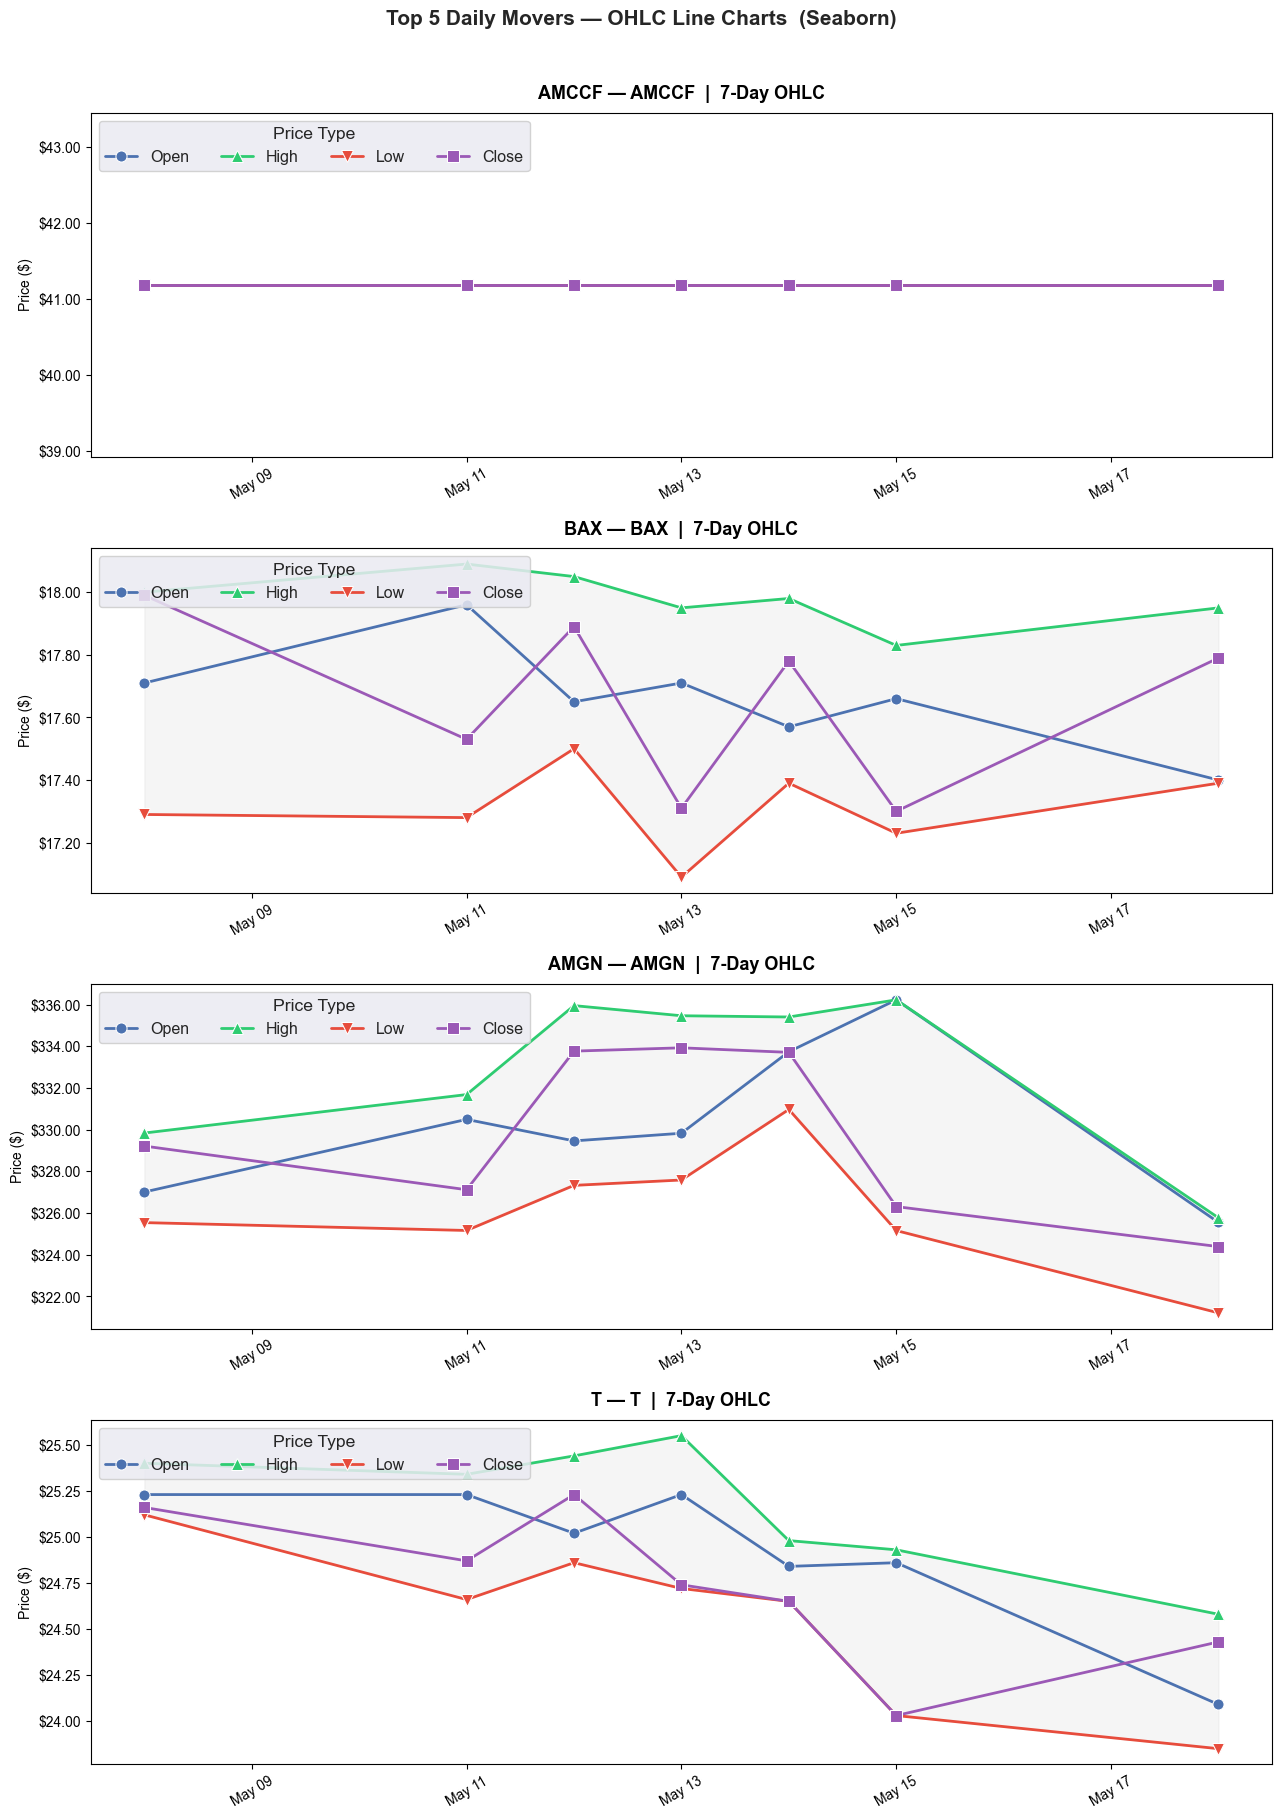

  ✓ Chart 1 complete.

Rendering Chart 2 — Top 5 Movers Close Price Comparison …


C:\Users\jancq\AppData\Local\Temp\ipykernel_16860\552383321.py:105: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jancq\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


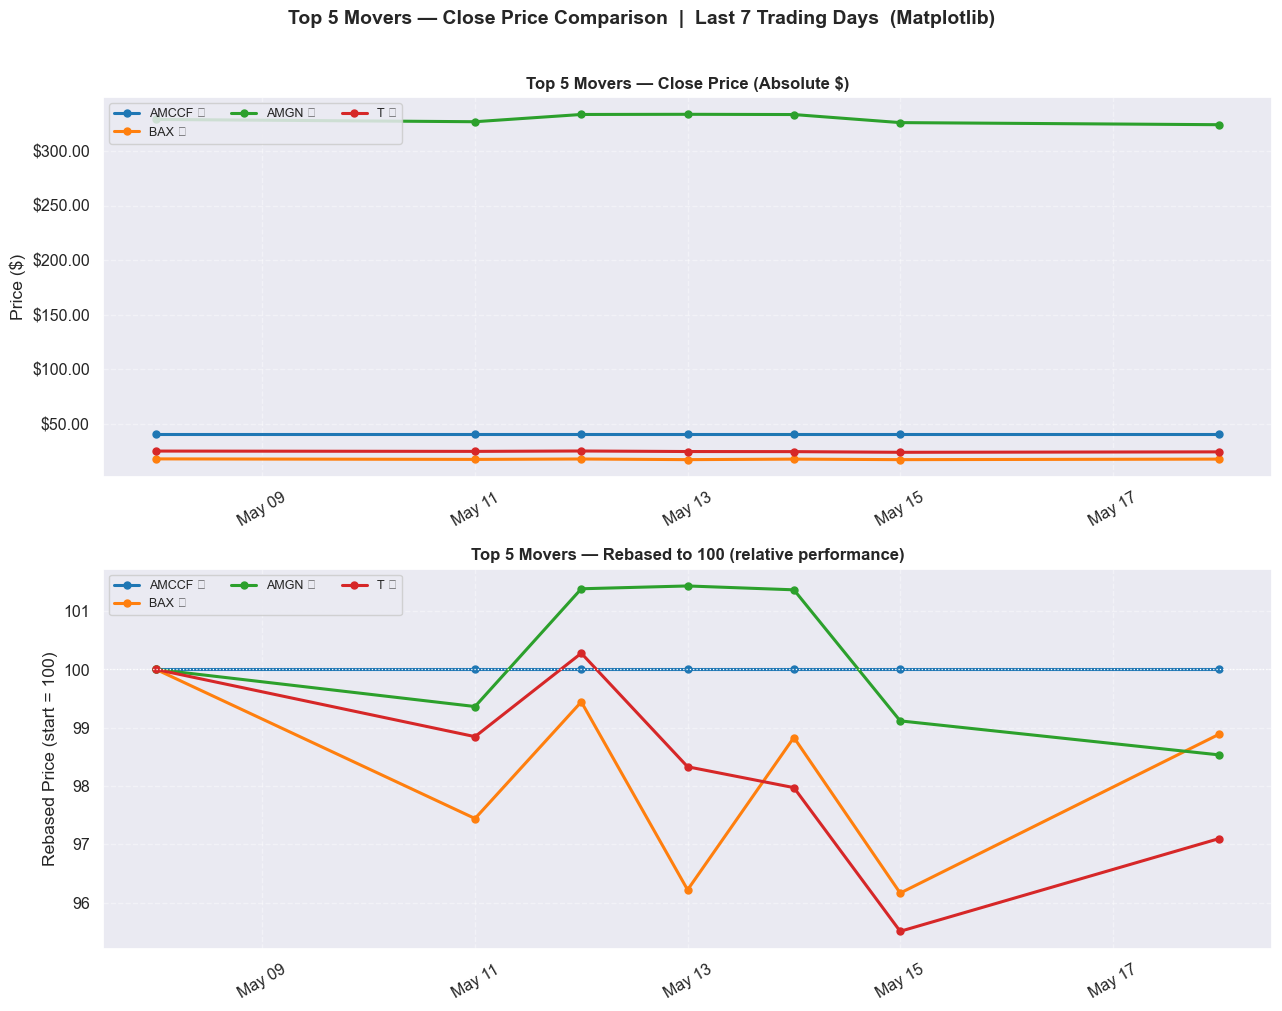

  ✓ Chart 2 complete.

 ✅ Cell 2 complete — run Cell 3 for watchlist charts.


In [2]:
# =============================================================================
# CELL 2 — TOP 5 MOVERS VISUALIZATIONS
# Requires: ohlc_data  (from Cell 1)
# Charts:
#   [1] Seaborn    — Top 5 Movers OHLC line charts (one per stock, faceted)
#   [2] Matplotlib — Top 5 Movers close price comparison (absolute + rebased)
# =============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import pandas as pd

# Guard
if not globals().get("ohlc_data"):
    raise RuntimeError("ohlc_data is missing — run Cell 1 first.")

OHLC_COLORS  = {"Open": "#4C72B0", "High": "#2ecc71", "Low": "#e74c3c", "Close": "#9b59b6"}
OHLC_MARKERS = {"Open": "o",       "High": "^",        "Low": "v",       "Close": "s"}

def dollar_fmt(v, _): return f"${v:,.2f}"


# CHART 1 — Seaborn: Top 5 Movers OHLC Line Charts (faceted, one per stock)
print("Rendering Chart 1 — Top 5 Movers OHLC …")

n = len(ohlc_data)
fig, axes = plt.subplots(n, 1, figsize=(13, 4.5 * n))
axes = [axes] if n == 1 else list(axes)

sns.set_theme(style="darkgrid", palette="tab10", font_scale=1.05)

for ax, (sym, df) in zip(axes, ohlc_data.items()):
    df_long = (
        df.reset_index()
          .rename(columns={"index": "Date"})
          .melt(id_vars="Date", var_name="Price Type", value_name="Price")
    )
    for pt in ["Open", "High", "Low", "Close"]:
        sub = df_long[df_long["Price Type"] == pt]
        sns.lineplot(
            data=sub, x="Date", y="Price", ax=ax,
            label=pt, color=OHLC_COLORS[pt],
            marker=OHLC_MARKERS[pt], linewidth=2, markersize=8,
        )

    ax.fill_between(df.index, df["Low"], df["High"],
                    alpha=0.08, color="#888888", label="_nolegend_")

    company = get_company_name(sym)
    ax.set_title(f"{sym} — {company}  |  {OHLC_DAYS}-Day OHLC",
                 fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Price ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Price Type", loc="upper left", framealpha=0.85, ncol=4)

fig.suptitle("Top 5 Daily Movers — OHLC Line Charts  (Seaborn)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("  ✓ Chart 1 complete.\n")


# CHART 2 — Matplotlib: Top 5 Movers Close Price Comparison
print("Rendering Chart 2 — Top 5 Movers Close Price Comparison …")

fig, (ax_abs, ax_norm) = plt.subplots(2, 1, figsize=(13, 10))
cmap   = plt.get_cmap("tab10")
colors = {sym: cmap(i % 10) for i, sym in enumerate(ohlc_data)}

for sym, df in ohlc_data.items():
    label = f"{sym} ★"
    ax_abs.plot(df.index, df["Close"],
                color=colors[sym], linewidth=2.2,
                marker="o", markersize=5, label=label)
    rebased = df["Close"] / df["Close"].iloc[0] * 100
    ax_norm.plot(df.index, rebased,
                 color=colors[sym], linewidth=2.2,
                 marker="o", markersize=5, label=label)

ax_abs.set_title("Top 5 Movers — Close Price (Absolute $)",
                 fontsize=12, fontweight="bold")
ax_abs.set_ylabel("Price ($)")
ax_abs.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax_abs.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_abs.tick_params(axis="x", rotation=30)
ax_abs.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_abs.grid(True, linestyle="--", alpha=0.4)

ax_norm.axhline(100, color="white", linewidth=0.9, linestyle=":")
ax_norm.set_title("Top 5 Movers — Rebased to 100 (relative performance)",
                  fontsize=12, fontweight="bold")
ax_norm.set_ylabel("Rebased Price (start = 100)")
ax_norm.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_norm.tick_params(axis="x", rotation=30)
ax_norm.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_norm.grid(True, linestyle="--", alpha=0.4)

fig.suptitle(f"Top 5 Movers — Close Price Comparison  |  Last {OHLC_DAYS} Trading Days  (Matplotlib)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("  ✓ Chart 2 complete.\n")

print("=" * 65)
print(" ✅ Cell 2 complete — run Cell 3 for watchlist charts.")
print("=" * 65)

## Watchlist Analysis & Visualization

This section monitors your favorite stocks (AAPL, NVDA, MSFT, META, GOOGL) for:
- Daily performance (% change from previous close)
- 7-day price trends (Open, High, Low, Close)

**Execution Flow**:
- Fetch watchlist performance & OHLC data → Creates `watchlist_ohlc_data`
- Visualize the watchlist data using matplotlib

## Watchlist - 7-Day OHLC Visualization

Visualize your watchlist stocks with detailed OHLC charts showing 7-day price movements.

**Data Source**: `watchlist_ohlc_data` from Cell 4
**Requirements**: Cell 4 must be executed first with successful data fetch

Rendering Chart 1 — Watchlist % Change …


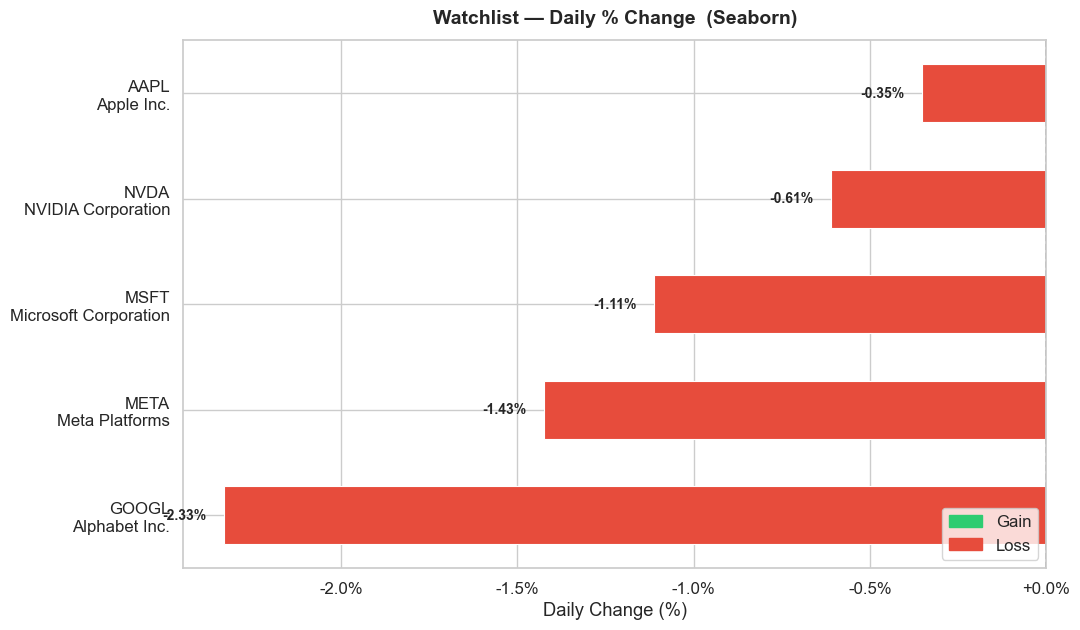

  ✓ Chart 1 complete.

Rendering Chart 2 — Watchlist Candlestick OHLC …


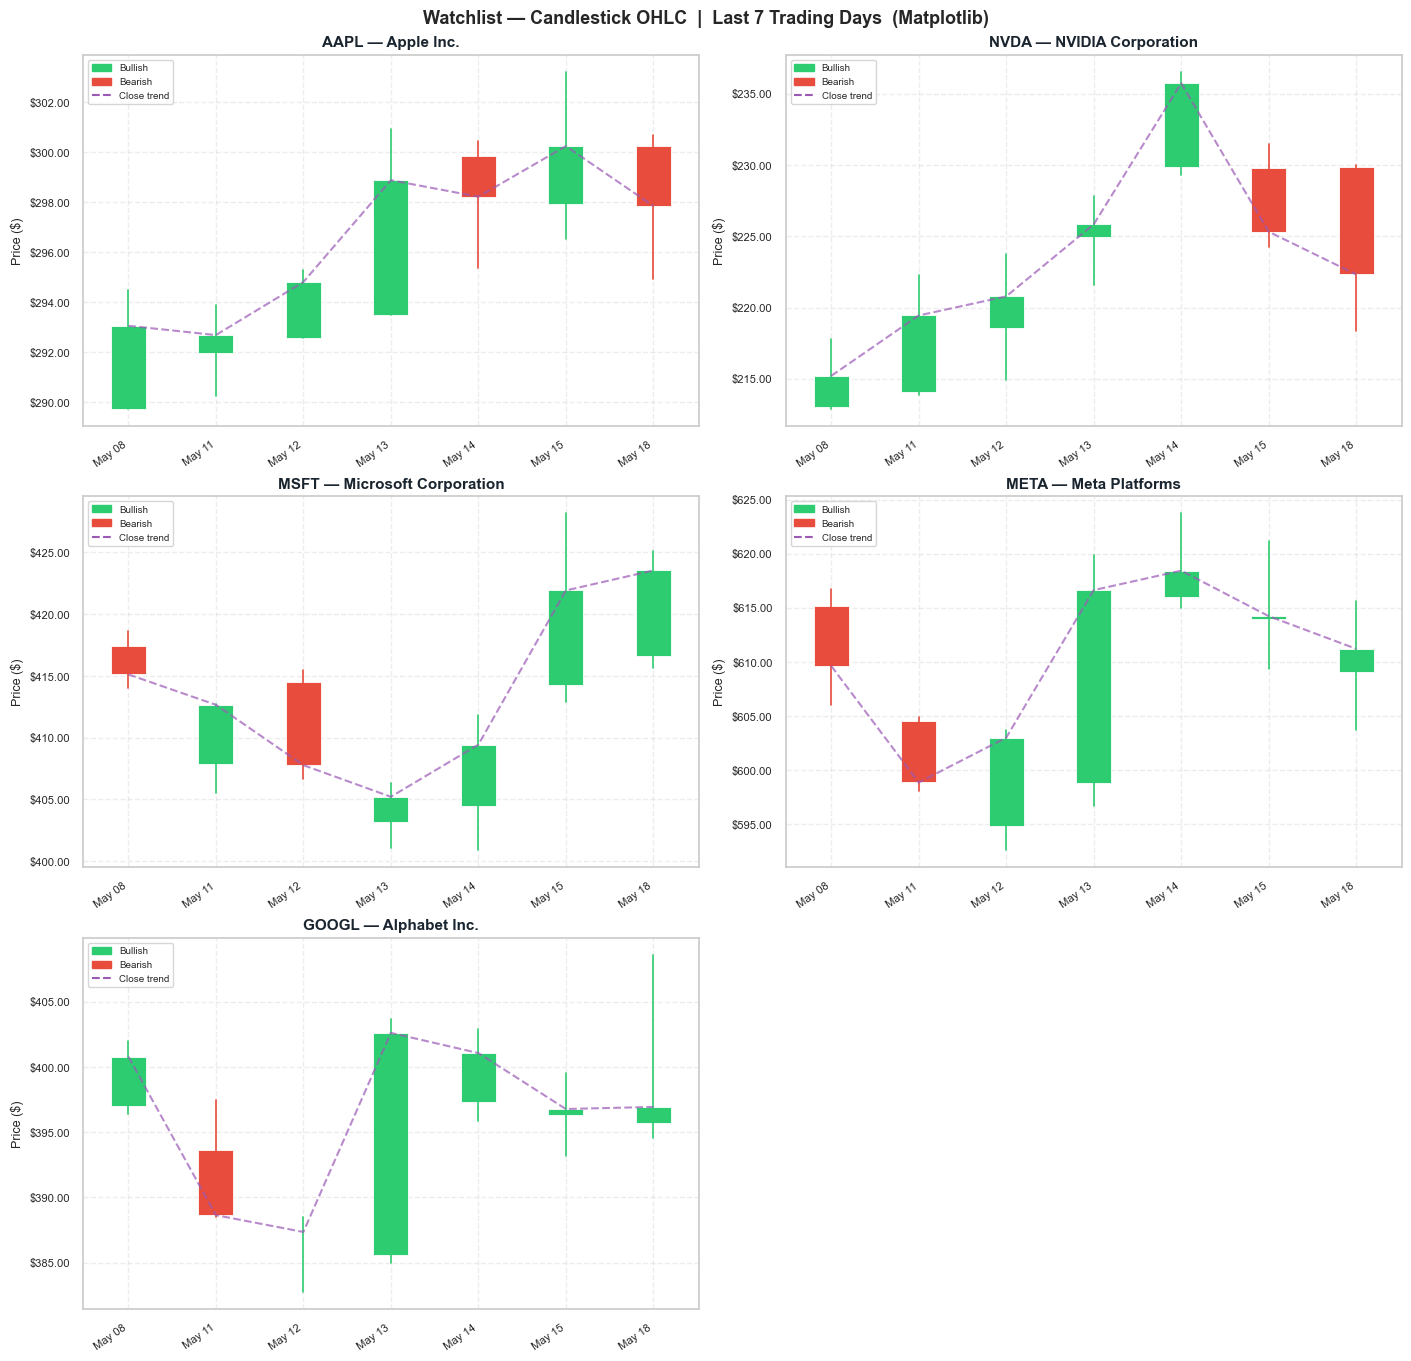

  ✓ Chart 2 complete.

Rendering Chart 3 — Watchlist Close Price Comparison …


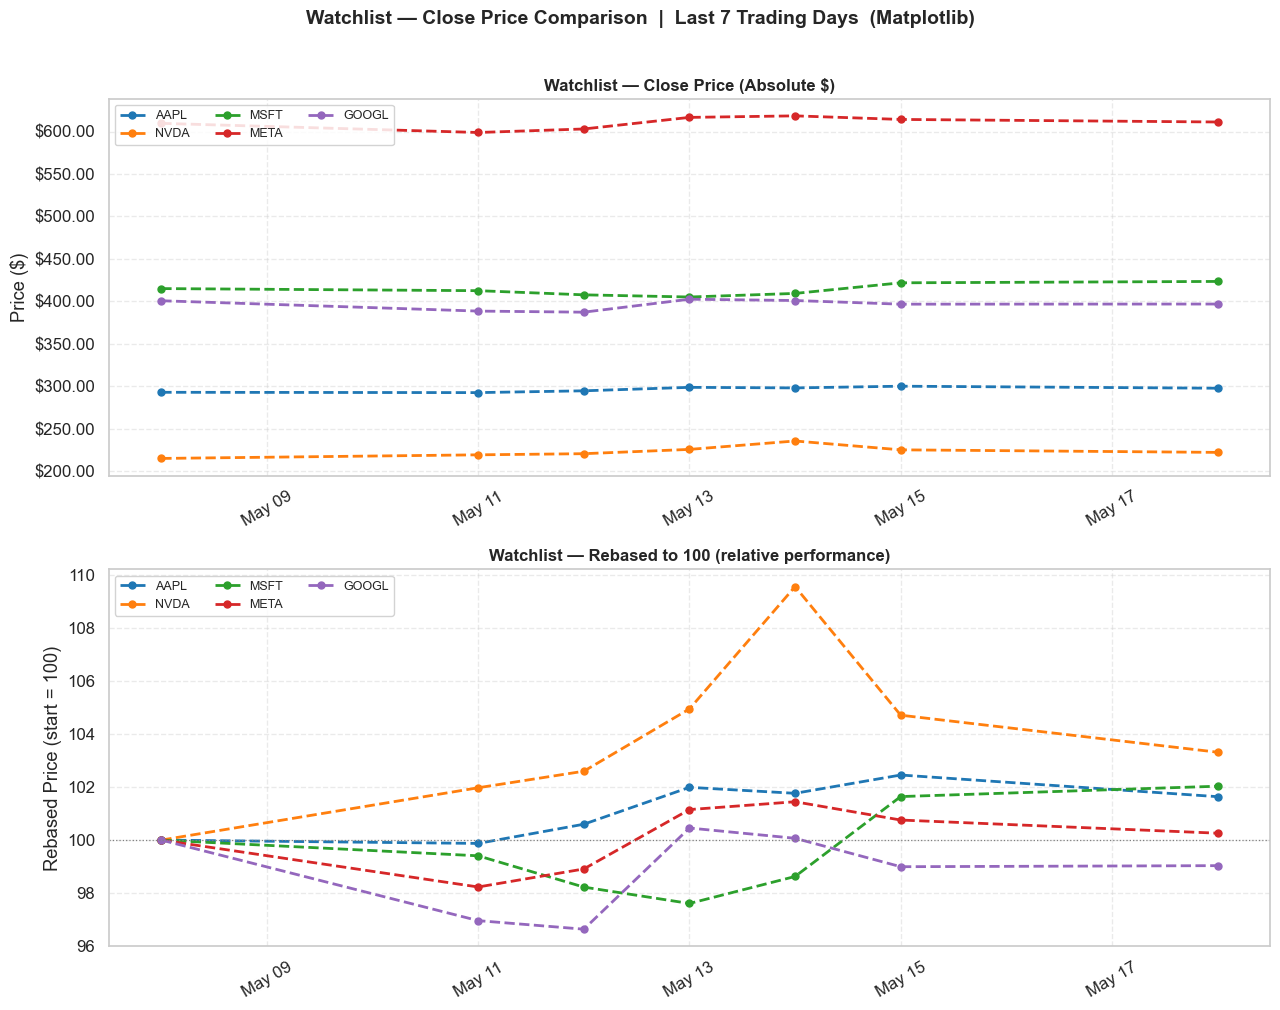

  ✓ Chart 3 complete.

 ✅ Cell 3 complete — all watchlist charts rendered.


In [3]:
# =============================================================================
# CELL 3 — WATCHLIST VISUALIZATIONS
# Requires: watchlist_ohlc_data, watchlist_performance  (from Cell 1)
# Charts:
#   [1] Seaborn    — Watchlist daily % change bar chart
#   [2] Matplotlib — Watchlist candlestick-style OHLC subplots
#   [3] Matplotlib — Watchlist close price comparison (absolute + rebased)
# =============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Guard
_missing = [n for n, v in [
    ("watchlist_ohlc_data",   globals().get("watchlist_ohlc_data")),
    ("watchlist_performance", globals().get("watchlist_performance")),
] if not v]
if _missing:
    raise RuntimeError(f"Missing from Cell 1: {_missing} — run Cell 1 first.")

def dollar_fmt(v, _): return f"${v:,.2f}"
def pct_fmt(v, _):    return f"{v:+.1f}%"

# CHART 1 — Seaborn: Watchlist Daily % Change Bar Chart
print("Rendering Chart 1 — Watchlist % Change …")

sns.set_theme(style="whitegrid", font_scale=1.1)

perf_df = pd.DataFrame(watchlist_performance, columns=["Symbol", "Pct"])
perf_df["Company"] = perf_df["Symbol"].map(get_company_name)
perf_df["Label"]   = perf_df["Symbol"] + "\n" + perf_df["Company"]
perf_df["Color"]   = perf_df["Pct"].apply(lambda v: "#2ecc71" if v >= 0 else "#e74c3c")
perf_df = perf_df.sort_values("Pct")

fig, ax = plt.subplots(figsize=(11, max(4, 0.9 * len(perf_df) + 2)))

bars = ax.barh(perf_df["Label"], perf_df["Pct"],
               color=perf_df["Color"].tolist(),
               edgecolor="white", linewidth=0.8, height=0.55)

for bar, val in zip(bars, perf_df["Pct"]):
    pad = 0.05
    ha  = "left" if val >= 0 else "right"
    ax.text(val + (pad if val >= 0 else -pad),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.2f}%", va="center", ha=ha,
            fontsize=10, fontweight="bold")

ax.axvline(0, color="gray", linewidth=1.2, linestyle="--")
ax.set_title("Watchlist — Daily % Change  (Seaborn)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Daily Change (%)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))

gain_patch = mpatches.Patch(color="#2ecc71", label="Gain")
loss_patch = mpatches.Patch(color="#e74c3c", label="Loss")
ax.legend(handles=[gain_patch, loss_patch], loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.show()
print("  ✓ Chart 1 complete.\n")

# CHART 2 — Matplotlib: Watchlist Candlestick-style OHLC Subplots
print("Rendering Chart 2 — Watchlist Candlestick OHLC …")

n     = len(watchlist_ohlc_data)
ncols = 2
nrows = (n + 1) // ncols
fig, axs = plt.subplots(nrows, ncols,
                         figsize=(14, 4.5 * nrows),
                         constrained_layout=True)
axs_flat = list(axs.flatten()) if n > 1 else [axs]

for ax, (sym, df) in zip(axs_flat, watchlist_ohlc_data.items()):
    dates = np.arange(len(df))
    width = 0.4

    for i, (_, row) in enumerate(df.iterrows()):
        color  = "#2ecc71" if row["Close"] >= row["Open"] else "#e74c3c"
        bottom = min(row["Open"], row["Close"])
        height = abs(row["Close"] - row["Open"]) or 0.01
        ax.bar(i, height, bottom=bottom, width=width,
               color=color, edgecolor="white", linewidth=0.6)
        ax.plot([i, i], [row["Low"], row["High"]],
                color=color, linewidth=1.2)

    # Close trend overlay
    ax.plot(dates, df["Close"].values, color="#9b59b6",
            linewidth=1.5, linestyle="--", alpha=0.7, label="Close trend")

    company = get_company_name(sym)
    ax.set_title(f"{sym} — {company}", fontsize=11,
                 fontweight="bold", color="#1a252f")
    ax.set_ylabel("Price ($)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
    ax.set_xticks(dates)
    ax.set_xticklabels(
        [d.strftime("%b %d") for d in df.index],
        rotation=35, ha="right", fontsize=8
    )
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.35)

    up_p   = mpatches.Patch(color="#2ecc71", label="Bullish")
    down_p = mpatches.Patch(color="#e74c3c", label="Bearish")
    ax.legend(handles=[up_p, down_p,
                        plt.Line2D([0], [0], color="#9b59b6",
                                   linestyle="--", label="Close trend")],
              fontsize=7, loc="upper left", framealpha=0.8)

for ax in axs_flat[n:]:
    ax.set_visible(False)

fig.suptitle(
    f"Watchlist — Candlestick OHLC  |  Last {OHLC_DAYS} Trading Days  (Matplotlib)",
    fontsize=13, fontweight="bold"
)
plt.show()
print("  ✓ Chart 2 complete.\n")

# CHART 3 — Matplotlib: Watchlist Close Price Comparison (absolute + rebased)
print("Rendering Chart 3 — Watchlist Close Price Comparison …")

fig, (ax_abs, ax_norm) = plt.subplots(2, 1, figsize=(13, 10))
cmap   = plt.get_cmap("tab10")
colors = {sym: cmap(i % 10) for i, sym in enumerate(watchlist_ohlc_data)}

for sym, df in watchlist_ohlc_data.items():
    ax_abs.plot(df.index, df["Close"],
                color=colors[sym], linewidth=2,
                linestyle="--", marker="o", markersize=5, label=sym)
    rebased = df["Close"] / df["Close"].iloc[0] * 100
    ax_norm.plot(df.index, rebased,
                 color=colors[sym], linewidth=2,
                 linestyle="--", marker="o", markersize=5, label=sym)

ax_abs.set_title("Watchlist — Close Price (Absolute $)",
                 fontsize=12, fontweight="bold")
ax_abs.set_ylabel("Price ($)")
ax_abs.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax_abs.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_abs.tick_params(axis="x", rotation=30)
ax_abs.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_abs.grid(True, linestyle="--", alpha=0.4)

ax_norm.axhline(100, color="gray", linewidth=0.9, linestyle=":")
ax_norm.set_title("Watchlist — Rebased to 100 (relative performance)",
                  fontsize=12, fontweight="bold")
ax_norm.set_ylabel("Rebased Price (start = 100)")
ax_norm.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax_norm.tick_params(axis="x", rotation=30)
ax_norm.legend(fontsize=9, loc="upper left", framealpha=0.85, ncol=3)
ax_norm.grid(True, linestyle="--", alpha=0.4)

fig.suptitle(f"Watchlist — Close Price Comparison  |  Last {OHLC_DAYS} Trading Days  (Matplotlib)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("  ✓ Chart 3 complete.\n")

print("=" * 65)
print(" ✅ Cell 3 complete — all watchlist charts rendered.")
print("=" * 65)